# UVP seminarska naloga – analiza prenosnikov

## Analiza obnovljenih prenosnikov na spletni strani Refurb.si

V seminarski nalogi sem analiziral ponudbo obnovljenih in novih prenosnikov na spletni strani Refurb.si. Analizo sem omejil na prenosnike s procesorjem Intel Core i7. S spletne strani sem s pomočjo knjižnic `requests` prenesel HTML kodo posameznih strani in z knjižnico `BeautifulSoup` izluščil podatke o podatkih on ponujenih prenosniki kot so specifikacije, cena ipd.

Največji problem pri podatkih je bil zapis številskih vrednosti. Cena je bila zapisana kot besedilo z znakom za evro, SSD pa je bil pri nekaterih napravah izražen v gigabajtih in pri drugih v terabajtih. Pred analizo sem zato cene pretvoril v števila, SSD-je v gigabajte ter iz zapisov za RAM in zaslon odstranil merske enote.

Pri analizi sem želel ugotoviti, kako so cena, RAM, SSD, velikost zaslona in namenjenaka grafična kartica povezani med seboj. Rezultate sem prikazal s tabelami in grafi, izdelanimi s knjižnicama `pandas` in `matplotlib`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

podatki = pd.read_csv('prenosniki.csv')

# Cena: na primer 1.499,00 € pretvorimo v 1499.0.
podatki['cena_eur'] = (
    podatki['cena']
    .str.replace(' €', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

podatki['ram_gb'] = podatki['ram'].str.extract(r'(\d+)', expand=False).astype(float)
podatki['zaslon_in'] = podatki['zaslon'].str.replace('\"', '', regex=False).astype(float)

def pretvori_ssd(vrednost):
    if pd.isna(vrednost):
        return None
    stevilo, enota = vrednost.split()
    stevilo = float(stevilo)
    return stevilo * 1000 if enota == 'TB' else stevilo

podatki['ssd_gb'] = podatki['ssd'].apply(pretvori_ssd)
podatki['namenska_graficna'] = podatki['graficna'].notna()
podatki.head()

,ime,procesor,ram,ssd,zaslon,graficna,operacijski_sistem,cena,url,cena_eur,ram_gb,zaslon_in,ssd_gb,namenska_graficna
0,Prenosnik Microsoft Surface Laptop Studio 1 14...,Intel i7-11370H,32 GB,1 TB,NaN,RTX 3050,Win 11 Pro,"2.299,00 €",https://refurb.si/product/prenosnik-microsoft-...,2299.0,32.0,NaN,1000.0,True
1,Prenosnik Microsoft Surface Laptop Studio 1 14...,Intel i7-11370H,16 GB,512 GB,NaN,RTX 3050,Win 11 Pro,"1.999,00 €",https://refurb.si/product/prenosnik-microsoft-...,1999.0,16.0,NaN,512.0,True
2,Prenosnik Lenovo ThinkPad X1 Yoga G7,Intel i7-1265U,16 GB,512 GB,"14""",NaN,Win 11 Pro,"1.699,00 €",https://refurb.si/product/prenosnik-lenovo-thi...,1699.0,16.0,14.0,512.0,False
3,Laptop HP ZBook Studio 15 G8,Intel i7-11850H,32 GB,NaN,"15.6""",RTX A2000,Win 11 Pro,"1.399,00 €",https://refurb.si/product/laptop-hp-zbook-stud...,1399.0,32.0,15.6,NaN,True
4,Laptop Lenovo ThinkPad P16s G2,Intel i7-1370P,64 GB,1 TB,"16""",RTX A500,Win 11 Pro,"1.499,00 €",https://refurb.si/product/laptop-lenovo-thinkp...,1499.0,64.0,16.0,1000.0,True


## Osnovni pregled podatkov

Od 73 prenosnikov, ki mi jih je uspelo prenesti, imajo vsi zapisano ceno, RAM in velikost zaslona, pri treh manjka podatek o SSD-ju, pri enem pa podatek o operacijskem sistemu. Prazen podatek o grafični kartici sem obravnaval kot napravo brez zaznane namenjene grafične kartice.

Povprečna cena prenosnika znaša 1.250,51 €, mediana pa 1.199 €. Najcenejši prenosnik stane 499 €, najdražji pa 2.999 €. Večina ponudbe je bližje mediani kot najvišji ceni, najdražji prenosnik pa odstopa od drugih.

In [2]:
print(f'Število prenosnikov: {len(podatki)}')
print(f'Število atributov v izvirni tabeli: 9')
print(f'Število podvojenih povezav: {podatki.duplicated(subset=["url"]).sum()}')
print('\nMANJKAJOČE VREDNOSTI')
print(podatki[['ime', 'procesor', 'ram', 'ssd', 'zaslon', 'graficna',
               'operacijski_sistem', 'cena', 'url']].isna().sum())
print('\nOSNOVNE STATISTIKE')
podatki[['cena_eur', 'ram_gb', 'ssd_gb', 'zaslon_in']].describe().round(2)

Število prenosnikov: 70
Število atributov v izvirni tabeli: 9
Število podvojenih povezav: 0

MANJKAJOČE VREDNOSTI
ime                    0
procesor               0
ram                    0
ssd                    4
zaslon                 2
graficna              28
operacijski_sistem     0
cena                   0
url                    0
dtype: int64

OSNOVNE STATISTIKE


,cena_eur,ram_gb,ssd_gb,zaslon_in
count,70.00,70.00,66.00,68.00
mean,1247.00,23.89,570.06,15.49
std,385.49,12.74,193.01,1.19
min,499.00,8.00,256.00,13.00
25%,999.00,16.00,512.00,14.75
50%,1199.00,16.00,512.00,15.60
75%,1474.00,32.00,512.00,16.00
max,2499.00,64.00,1000.00,17.30


## Porazdelitev cen

S histogramom sem prikazal, v katerih cenovnih razredih je največ prenosnikov. Večina prenosnikov stane med približno 900 € in 1.500 €, nad 2.000 € pa so le posamezni zmogljivejši modeli.

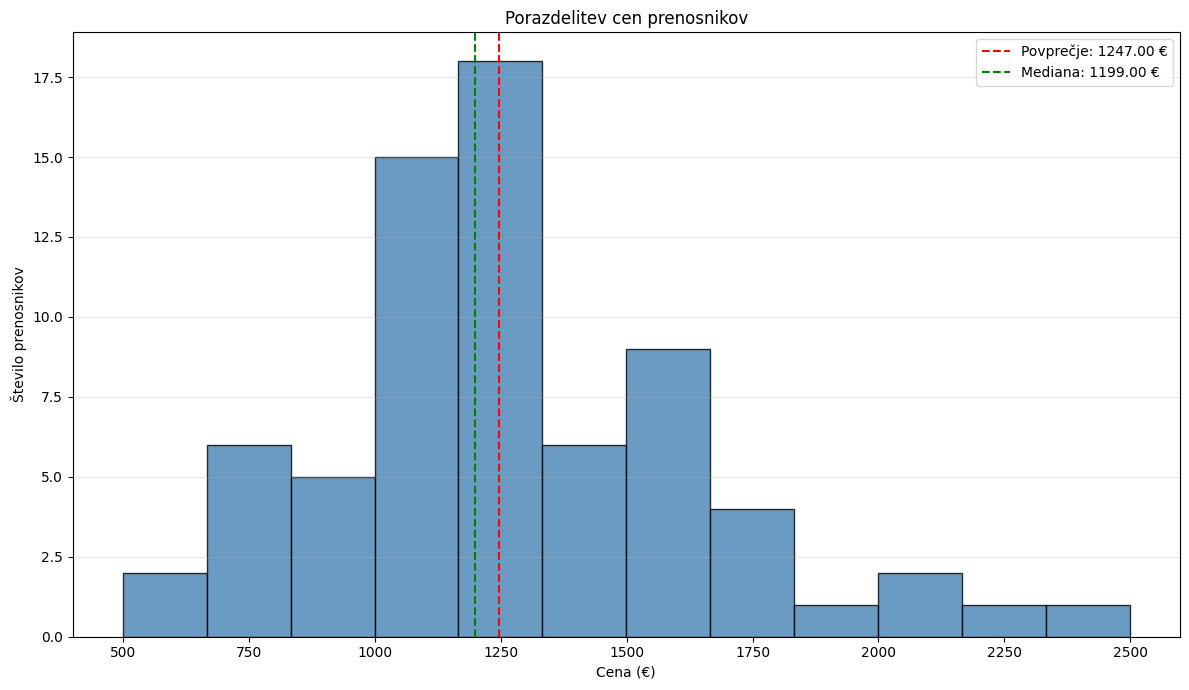

In [3]:
plt.figure(figsize=(12, 7))
plt.hist(podatki['cena_eur'], bins=12, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(podatki['cena_eur'].mean(), color='red', linestyle='--',
            label=f"Povprečje: {podatki['cena_eur'].mean():.2f} €")
plt.axvline(podatki['cena_eur'].median(), color='green', linestyle='--',
            label=f"Mediana: {podatki['cena_eur'].median():.2f} €")
plt.title('Porazdelitev cen prenosnikov')
plt.xlabel('Cena (€)')
plt.ylabel('Število prenosnikov')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Najdražji in najcenejši prenosniki

Nato sem poiskal pet najdražjih in pet najcenejših naprav. Najdražji je Microsoft Surface Laptop Studio 2 s ceno 2.999 €, 32 GB RAM-a, 1 TB SSD-jem in grafično kartico RTX 4050. Najcenejša sta Dell Precision 7720 in Lenovo ThinkPad X1 Yoga G3, ki staneta 499 €.

In [4]:
stolpci = ['ime', 'procesor', 'ram', 'ssd', 'graficna', 'cena_eur']

print('PET NAJDRAŽJIH PRENOSNIKOV')
display(podatki.nlargest(5, 'cena_eur')[stolpci].reset_index(drop=True))

print('PET NAJCENEJŠIH PRENOSNIKOV')
display(podatki.nsmallest(5, 'cena_eur')[stolpci].reset_index(drop=True))

PET NAJDRAŽJIH PRENOSNIKOV


,ime,procesor,ram,ssd,graficna,cena_eur
0,HP ZBook Fury 16 G9,Intel Core i7,32 GB,512 GB,RTX A4500,2499.0
1,Prenosnik Microsoft Surface Laptop Studio 1 14...,Intel i7-11370H,32 GB,1 TB,RTX 3050,2299.0
2,Prenosnik Microsoft Surface Laptop Studio 1 14...,Intel i7-11370H,16 GB,512 GB,RTX 3050,1999.0
3,Laptop Dell Precision 7760,Intel i7-11850H,64 GB,512 GB,RTX A5000,1999.0
4,Laptop Lenovo ThinkPad P17 G2,Intel Core i7,32 GB,512 GB,RTX A3000,1899.0


PET NAJCENEJŠIH PRENOSNIKOV


,ime,procesor,ram,ssd,graficna,cena_eur
0,Laptop Dell Precision 7720,Intel i7-7700HQ,16 GB,512 GB,Quadro P3000,499.0
1,Laptop Lenovo Thinkpad X1 Yoga G3,Intel i7-8550U,8 GB,256 GB,NaN,499.0
2,Laptop Dell Precision 7530,Intel Core i7,16 GB,256 GB,Quadro P2000,699.0
3,Tablet HP Elite X2 G4,Intel i7-8565U,16 GB,256 GB,NaN,699.0
4,Laptop Dell Precision 7560,Intel i7-11850H,16 GB,512 GB,Quadro T1200,699.0


## Vpliv velikosti RAM-a na ceno

Prenosnike sem združil glede na količino RAM-a in za vsako skupino izračunal povprečno ceno. Največ naprav ima 16 GB RAM-a, in sicer 38, sledi 26 naprav z 32 GB. Prenosniki z 8 GB RAM-a v povprečju stanejo 899 €, s 16 GB 1.066,11 €, z 32 GB 1.480,15 € in s 64 GB 1.739 €.

Povprečna cena se torej z večanjem količine RAM-a povečuje. Cene pa niso odvisne le od RAM-a. Rast cen je povezana tudi s tem, da imajo prenosniki z več RAM-a tudi boljšo ostalo opremo.

,stevilo,povprecna_cena,mediana
ram_gb,,,
8.0,3,832.33,999.0
16.0,39,1107.97,999.0
32.0,24,1449.42,1349.0
64.0,4,1699.00,1649.0


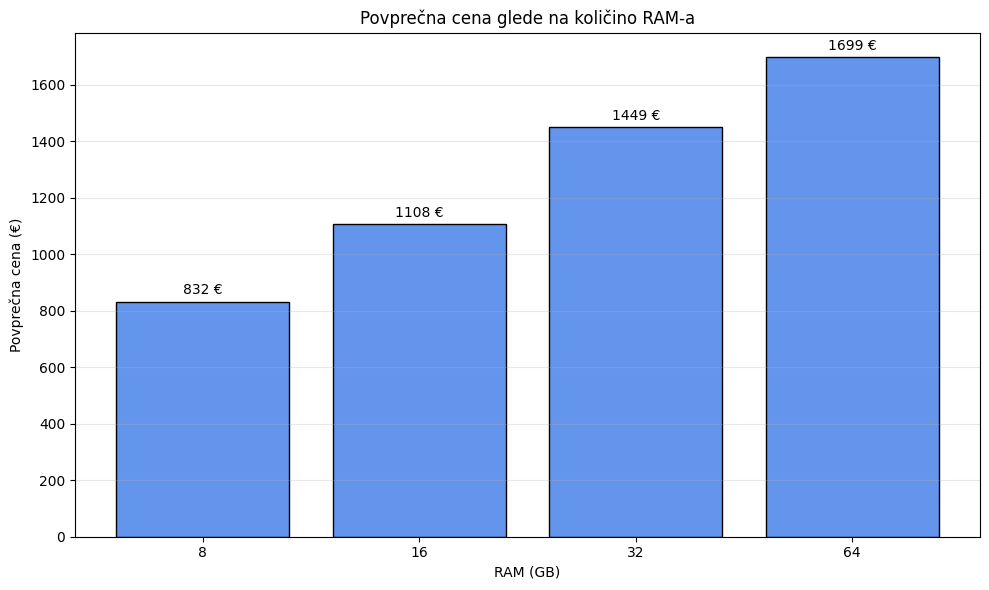

In [5]:
ram_statistika = podatki.groupby('ram_gb').agg(
    stevilo=('ime', 'size'),
    povprecna_cena=('cena_eur', 'mean'),
    mediana=('cena_eur', 'median')
).round(2)
display(ram_statistika)

plt.figure(figsize=(10, 6))
stolpci_ram = plt.bar(
    ram_statistika.index.astype(int).astype(str),
    ram_statistika['povprecna_cena'],
    color='cornflowerblue', edgecolor='black'
)
plt.bar_label(stolpci_ram, fmt='%.0f €', padding=3)
plt.title('Povprečna cena glede na količino RAM-a')
plt.xlabel('RAM (GB)')
plt.ylabel('Povprečna cena (€)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Vpliv velikosti SSD-ja na ceno

Pri SSD-jih sem vse vrednosti najprej pretvoril v gigabajte, pri čemer sem 1 TB zapisal kot 1000 GB. Najpogostejši je 512 GB SSD, ki ga ima 51 od 70 prenosnikov z znanim podatkom. Prenosniki z 256 GB SSD-jem stanejo povprečno 819 €, tisti s 512 GB 1.209,98 €, naprave z 1 TB pa 1.632,33 €.

Tudi tukaj opazimo rast povprečne cene z večanjem prostora za shranjevanje. Skupina s 500 GB vsebuje samo dve napravi, zato njeno povprečje ni dovolj zanesljivo za splošen sklep.

,stevilo,povprecna_cena
ssd_gb,,
256.0,4,749.0
500.0,2,1299.0
512.0,50,1230.2
1000.0,10,1549.0


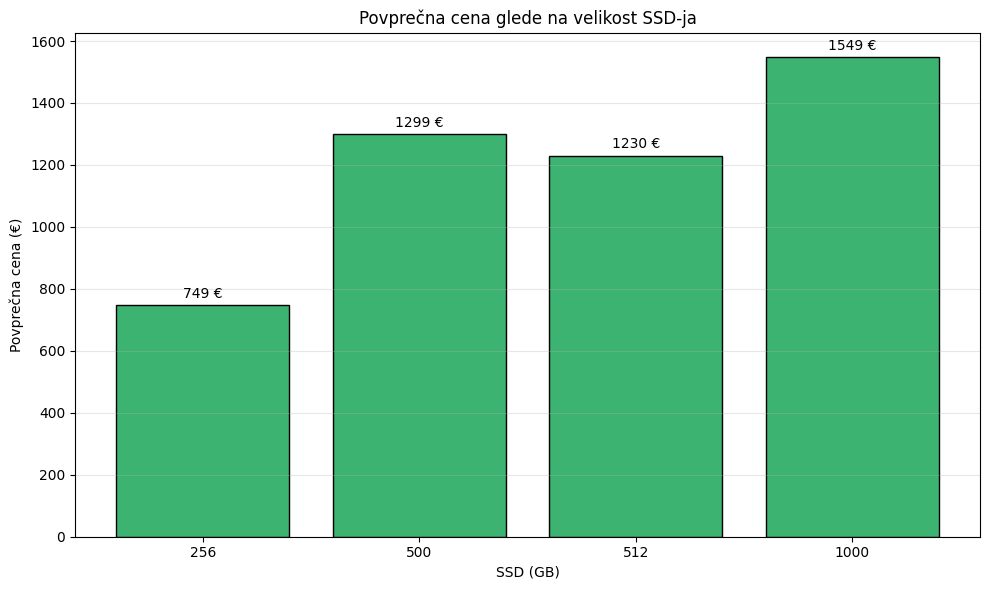

In [6]:
ssd_statistika = podatki.dropna(subset=['ssd_gb']).groupby('ssd_gb').agg(
    stevilo=('ime', 'size'),
    povprecna_cena=('cena_eur', 'mean')
).round(2)
display(ssd_statistika)

plt.figure(figsize=(10, 6))
stolpci_ssd = plt.bar(
    ssd_statistika.index.astype(int).astype(str),
    ssd_statistika['povprecna_cena'],
    color='mediumseagreen', edgecolor='black'
)
plt.bar_label(stolpci_ssd, fmt='%.0f €', padding=3)
plt.title('Povprečna cena glede na velikost SSD-ja')
plt.xlabel('SSD (GB)')
plt.ylabel('Povprečna cena (€)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Namenska grafična kartica in cena

V podatkih ima 44 prenosnikov zapisano grafično kartico iz družine RTX ali Quadro, pri 29 pa namenska grafična kartica ni navedena. Prenosniki z namensko grafično kartico v povprečju stanejo 1.379,68 €, drugi pa 1.054,52 €. Razlika v povprečni ceni znaša približno 325 €.

To je pričakovan rezultat, saj so namenske grafične kartice namenjene zahtevnejšemu grafičnemu delu.

,stevilo,povprecna_cena,mediana
Ni navedena,28,1063.64,999.0
RTX ali Quadro,42,1369.24,1299.0


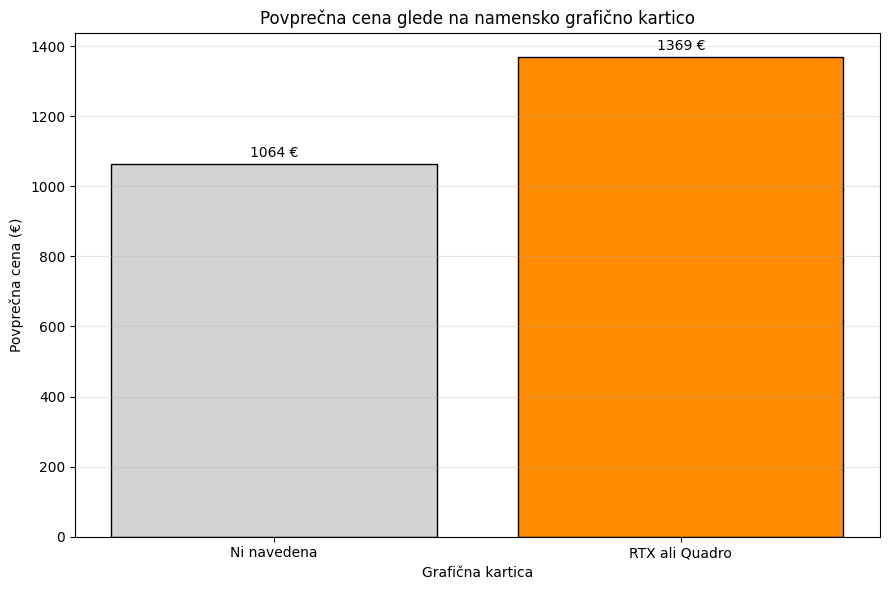

In [7]:
gpu_statistika = podatki.groupby('namenska_graficna').agg(
    stevilo=('ime', 'size'),
    povprecna_cena=('cena_eur', 'mean'),
    mediana=('cena_eur', 'median')
).round(2)
gpu_statistika.index = ['Ni navedena', 'RTX ali Quadro']
display(gpu_statistika)

plt.figure(figsize=(9, 6))
stolpci_gpu = plt.bar(
    gpu_statistika.index, gpu_statistika['povprecna_cena'],
    color=['lightgray', 'darkorange'], edgecolor='black'
)
plt.bar_label(stolpci_gpu, fmt='%.0f €', padding=3)
plt.title('Povprečna cena glede na namensko grafično kartico')
plt.xlabel('Grafična kartica')
plt.ylabel('Povprečna cena (€)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Zaključek

Z analizo sem ugotovil, da spletna stran trenutno ponuja 73 različnih prenosnikov s procesorjem Intel Core i7. Tipičen prenosnik v podatkovni množici ima 16 GB RAM-a, 512 GB SSD in 15,6-palčni zaslon, mediana cene pa znaša 1199 €.

Najbolj očitna povezava je med količino RAM-a in ceno. Prenosniki z več RAM-a so v povprečju dražji, podobno velja tudi za večje SSD-je. Prenosniki z navedeno namensko grafično kartico RTX ali Quadro so v povprečju približno 325 € dražji od naprav, pri katerih taka kartica ni navedena. Velikost zaslona pa s ceno ni povezana.

Treba je upoštevati, da podatki prikazujejo trenutno ponudbo samo ene spletne trgovine in samo modele s procesorjem Intel Core i7. Poleg tega na ceno vplivajo še generacija procesorja, starost naprave ter stanje obnovljenega prenosnika in kakovost izdelave, ki jih v tej analizi nisem podrobneje obravnaval. Analizo je mogoče nadgraditi z izločanjem generacije procesorja in spremljanjem spreminjanja cen skozi čas.